# Lab: Linear Programming

Lab associated with Module 9: Linear Programming

***

In [1]:
# The following lines are used to increase the width of cells to utilize more space on the screen 
from IPython.display import display, HTML  # IPython.core.display is deprecated
display(HTML("<style>.container { width:95% !important; }</style>"))

***

### Section 0: Imports

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
from fractions import Fraction   # exact arithmetic for the simplex tableau in Activity 4

***

### Section 1: Solving LP problem graphically

Let us see if we can solve the LP problem that we discussed in the lecture, graphically

In [5]:
X1 = np.linspace(0, 1000)

In [6]:
# X1 + X2 >= 200
# X2 = 200 - X1
X2 = 200 - X1

In [7]:
#2X1 + 3X2 <= 120
#X2 = (120 - 2X1)/2

In [8]:
X2x = X1[np.where(X2 > 0)[0]]
X2y = X2[np.where(X2 > 0)[0]]

In [9]:
# 9X1 + 6X2 <= 1556
# X2 = (1556 - 9X1)/6

X3 = (1556 - 9*X1)/6

X3x = X1[np.where(X3 > 0)[0]]
X3y = X3[np.where(X3 > 0)[0]]

In [10]:
# 12X1 + 16X2 <= 2880
# X2 = (2880 - 12X1)/16

X4 = (2880 - 12*X1)/16

X4x = X1[np.where(X4 > 0)[0]]
X4y = X4[np.where(X4 > 0)[0]]

Let us plot these constraints

Text(0, 0.5, 'X2')

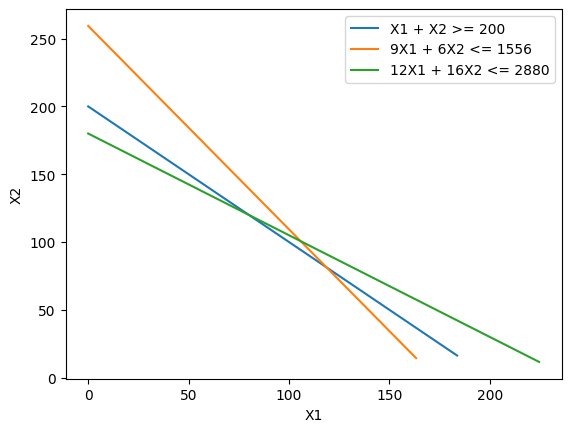

In [11]:
plt.plot(X2x, X2y, label=r'$2y\leq25-x$')
plt.plot(X3x, X3y, label=r'$2y\leq25-x$')
plt.plot(X4x, X4y, label=r'$2y\leq25-x$')

plt.legend(['X1 + X2 >= 200', '9X1 + 6X2 <= 1556', '12X1 + 16X2 <= 2880'])
plt.xlabel('X1')
plt.ylabel('X2')

Let us see if we can plot the feasible region

Text(0, 0.5, 'X2')

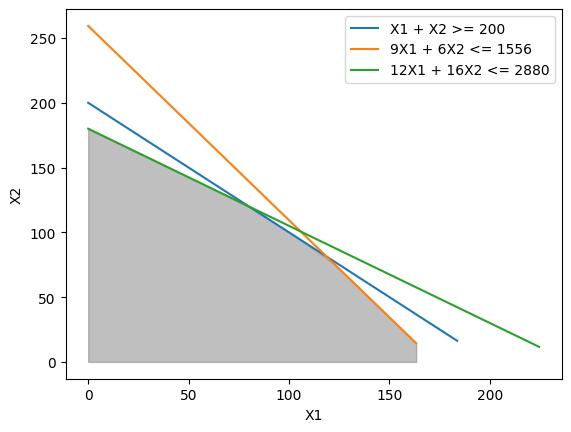

In [12]:
plt.plot(X2x, X2y, label=r'$2y\leq25-x$')
plt.plot(X3x, X3y, label=r'$2y\leq25-x$')
plt.plot(X4x, X4y, label=r'$2y\leq25-x$')

# Fill feasible region
y5 = np.minimum(X2y[0:9], X3y)
y6 = np.minimum(y5, X4y[0:9])
plt.fill_between(X4x[0:9], y6, color='grey', alpha=0.5)

plt.legend(['X1 + X2 >= 200', '9X1 + 6X2 <= 1556', '12X1 + 16X2 <= 2880'])
plt.xlabel('X1')
plt.ylabel('X2')

Okay, now we have the constraints, let us see if we can plot the various values of objective function

Text(0, 0.5, 'X2')

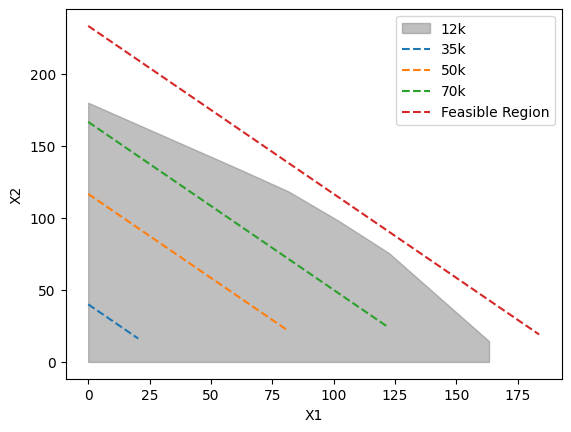

In [13]:
# 350X1 + 300X2
# X2 = (N - 350X1)/300
N1 = 12000
N2 = 35000
N3 = 50000
N4 = 70000

X5_1 = (N1 - 350*X1)/300
X5_2 = (N2 - 350*X1)/300
X5_3 = (N3 - 350*X1)/300
X5_4 = (N4 - 350*X1)/300

# Fill feasible region
y5 = np.minimum(X2y[0:9], X3y)
y6 = np.minimum(y5, X4y[0:9])
plt.fill_between(X4x[0:9], y6, color='grey', alpha=0.5)

# No need to plot the constraints

#plt.plot(X2x, X2y, label=r'$2y\leq25-x$')
#plt.plot(X3x, X3y, label=r'$2y\leq25-x$')
#plt.plot(X4x, X4y, label=r'$2y\leq25-x$')

X5_1x = X1[np.where(X5_1 > 0)[0]]
X5_1y = X5_1[np.where(X5_1 > 0)[0]]

X5_2x = X1[np.where(X5_2 > 0)[0]]
X5_2y = X5_2[np.where(X5_2 > 0)[0]]

X5_3x = X1[np.where(X5_3 > 0)[0]]
X5_3y = X5_3[np.where(X5_3 > 0)[0]]

X5_4x = X1[np.where(X5_4 > 0)[0]]
X5_4y = X5_4[np.where(X5_4 > 0)[0]]

plt.plot(X5_1x, X5_1y, '--', label=r'$2y\leq25-x$')
plt.plot(X5_2x, X5_2y, '--', label=r'$2y\leq25-x$')
plt.plot(X5_3x, X5_3y, '--', label=r'$2y\leq25-x$')
plt.plot(X5_4x, X5_4y, '--', label=r'$2y\leq25-x$')

plt.legend(['12k', '35k', '50k', '70k','Feasible Region'])
plt.xlabel('X1')
plt.ylabel('X2')

### <font color='red'> Activity 1: Write code for solving a system of linear equations in form of y = Ax. Note, you should use LU decomposition algorithm that we discussed in the lecture, and then use forward and backward substitution to find a value of x. </font>

In [14]:
# what is expected: y = Ax
# y - Given, Vector (1d) [1, 2, 3, 4]
# A - Given, Matrix (2d) [[2, 3, 1 9],[1, 2, 3, 1],[0, 1, 2 ,3],[4, 1, 6, 6]]
# x - Not Given, Vector (1d) [x1, x2, x3, x4]

def sovleSystemLinearEquations(A, y):
    
    # A = LU
    L, U = LUDecomposition(A)
    
    # y = Ax -> y = LUx
    # Ux = b
    # y = Lb (y is known, L is known, but b is not known)
    
    b = forwardSub(L, y)
    
    # b = Ux (b is known, U is known, x is not known)
    x = backwardSub(U, b)
    
    return x


def LUDecomposition(A):
    """CLRS LU-DECOMPOSITION (28.1), no pivoting.

    Works on a copy of A. At step k the pivot is A[k][k]. Column k below the pivot,
    divided by the pivot, becomes column k of L. Row k from the pivot rightwards becomes
    row k of U. The trailing (n-k-1) x (n-k-1) block then gets the outer product
    L[:,k] * U[k,:] subtracted (the Schur complement), which is what makes the next
    pivot correct. Three nested loops, so O(n^3).
    """
    A = np.array(A, dtype=float).copy()      # never modify the caller's matrix
    n = len(A)
    L = np.eye(n)                            # unit lower triangular, 1s on the diagonal
    U = np.zeros((n, n))
    
    for k in range(0, n):
        U[k][k] = A[k][k]
        if U[k][k] == 0:
            raise ValueError(f"zero pivot at k={k}: this matrix needs LUP (row swaps), not plain LU")
        for i in range(k+1, n):
            L[i][k] = A[i][k] / U[k][k]       # multiplier that zeroes A[i][k]
            U[k][i] = A[k][i]                 # row k of U is row k of the current A
        for i in range(k+1, n):
            for j in range(k+1, n):
                A[i][j] = A[i][j] - L[i][k] * U[k][j]   # Schur complement update
    
    return L, U
    
def forwardSub(L, a):
    """Solve L b = a for b, top row first. L has 1s on the diagonal so there is no division.
    Row i of L has zeros to the right of column i, and b[j] for j > i is still 0 when row i
    is processed, so np.dot(b, L[i]) is exactly sum_{j<i} L[i][j] * b[j]. O(n^2)."""
    n = len(a)
    b = np.zeros(n)
    
    for i in range(0, n):
        b[i] = a[i] - np.dot(b, L[i])
        
    return b

def backwardSub(U, a):
    """Solve U b = a for b, bottom row first. Same trick as forwardSub, run in reverse,
    and this time the diagonal of U is not 1 so each step divides by U[i][i]. O(n^2)."""
    n = len(a)
    b = np.zeros(n)
    
    for i in range(n-1, -1, -1):
        b[i] = (a[i] - np.dot(b, U[i])) / U[i][i]
        
    return b



In [15]:
A = [[2, 3, 1, 9],
     [1, 2, 3, 1],
     [0, 1, 2, 3],
     [4, 1, 6, 6]]
y = [1, 2, 3, 4]

L, U = LUDecomposition(A)
print("L =\n", np.round(L, 4))
print("U =\n", np.round(U, 4))
print("L @ U == A :", np.allclose(L @ U, A))

x = sovleSystemLinearEquations(A, y)
print("\nx =", np.round(x, 6))
print("A @ x =", np.round(np.array(A) @ x, 10), "  (should be y =", y, ")")
print("matches numpy.linalg.solve:", np.allclose(x, np.linalg.solve(A, y)))

L =
 [[  1.       0.       0.       0.    ]
 [  0.5      1.       0.       0.    ]
 [  0.       2.       1.       0.    ]
 [  2.     -10.      -9.6667   1.    ]]
U =
 [[ 2.      3.      1.      9.    ]
 [ 0.      0.5     2.5    -3.5   ]
 [ 0.      0.     -3.     10.    ]
 [ 0.      0.      0.     49.6667]]
L @ U == A : True

x = [-1.147651 -0.308725  1.14094   0.342282]
A @ x = [1. 2. 3. 4.]   (should be y = [1, 2, 3, 4] )
matches numpy.linalg.solve: True


In [16]:
# The worked example from CLRS 28.1 (Figure 28.1). L and U should come out as integers.
A_clrs = [[2, 3, 1, 5],
          [6, 13, 5, 19],
          [2, 19, 10, 23],
          [4, 10, 11, 31]]
L, U = LUDecomposition(A_clrs)
print("L =\n", L)
print("U =\n", U)
print("L @ U == A :", np.allclose(L @ U, A_clrs))

L =
 [[1. 0. 0. 0.]
 [3. 1. 0. 0.]
 [1. 4. 1. 0.]
 [2. 1. 7. 1.]]
U =
 [[2. 3. 1. 5.]
 [0. 4. 2. 4.]
 [0. 0. 1. 2.]
 [0. 0. 0. 3.]]
L @ U == A : True


In [17]:
# Any square matrix and any y. Random 6x6 and 10x10 systems, checked against numpy.
rng = np.random.default_rng(320)
for n in [3, 6, 10]:
    A_r = rng.integers(-9, 10, size=(n, n)).astype(float) + n * np.eye(n)   # diagonal bump so no pivot is 0
    y_r = rng.integers(-20, 21, size=n).astype(float)
    x_r = sovleSystemLinearEquations(A_r, y_r)
    print(f"n={n:>2}  max |A x - y| = {np.max(np.abs(A_r @ x_r - y_r)):.2e}   matches numpy: {np.allclose(x_r, np.linalg.solve(A_r, y_r))}")

n= 3  max |A x - y| = 5.33e-15   matches numpy: True
n= 6  max |A x - y| = 1.42e-14   matches numpy: True
n=10  max |A x - y| = 1.78e-14   matches numpy: True


In [18]:
# The limit of plain LU: a matrix with a zero in the pivot position is nonsingular but LU cannot start on it.
A_bad = [[0, 1],
         [1, 0]]
try:
    LUDecomposition(A_bad)
except ValueError as e:
    print("LUDecomposition:", e)
print("numpy (which uses LUP) still solves it:", np.linalg.solve(A_bad, [1, 2]))

LUDecomposition: zero pivot at k=0: this matrix needs LUP (row swaps), not plain LU
numpy (which uses LUP) still solves it: [2. 1.]


### <font color='green'> Rough work for activity 1. </font>

In [19]:
# LU Decompostion Pseudo-code (CLRS 28.1), traced by hand on the CLRS example

n = 4
A = [[2, 3, 1, 5], [6, 13, 5, 19], [2, 19, 10, 23], [4, 10, 11, 31]]
L = [[1 if i == j else 0 for j in range(0,n)] for i in range(0, n)] # Take care of initialization of L: identity
U = [[0 for i in range(0,n)] for i in range(0, n)]

for k in range(0, n):
    
    U[k][k] = A[k][k]
    
    for i in range(k+1, n):
        L[i][k] = A[i][k] / U[k][k]
        U[k][i] = A[k][i]
    
    for i in range(k+1, n):
        for j in range(k+1, n):
            A[i][j] = A[i][j] - L[i][k] * U[k][j]


In [20]:
L

[[1, 0, 0, 0], [3.0, 1, 0, 0], [1.0, 4.0, 1, 0], [2.0, 1.0, 7.0, 1]]

In [21]:
U

[[2, 3, 1, 5], [0, 4.0, 2.0, 4.0], [0, 0, 1.0, 2.0], [0, 0, 0, 3.0]]

Forward substitution (strategy). Solve $La = b$ where $L$ is unit lower triangular:

```
L = [[1,    0,   0,  0]
     [l11,  1,   0,  0]
     [l21, l22,  1,  0]
     [l31, l32, l33, 1]]

a = [a1, a2, a3, a4]   # Not Given
b = [b1, b2, b3, b4]   # Given

# First case
1 * a1 = b1            ->  a1 = b1

# Second case
l11 * a1 + 1 * a2 = b2 ->  a2 = b2 - (l11 * a1)

# Third case
l21 * a1 + l22 * a2 + 1 * a3 = b3
                       ->  a3 = b3 - (l21 * a1 + l22 * a2)

# Fourth case
l31 * a1 + l32 * a2 + l33 * a3 + 1 * a4 = b4
                       ->  a4 = b4 - (l31 * a1 + l32 * a2 + l33 * a3)
```

Each unknown depends only on the ones above it, so one pass from the top solves the lot. Backward substitution is the same pass from the bottom, with a division by the diagonal entry of $U$ at every step.

In [22]:
def ForwardSub(L, b):
    
    n = len(b)
    
    a = [0 for i in range(0, n)]
    
    for i in range(0, n):
        a[i] = b[i] - np.dot(a, L[i])
        
    return a

In [23]:
# backward Substitution

def BackwardSub(U, b):
    
    n = len(b)
    
    a = [0 for i in range(0, n)]
    
    for i in range(n-1, -1, -1):
        a[i] = (b[i] - np.dot(a, U[i]))/U[i][i]
        
    return a

# check the rough-work versions agree with the Activity 1 versions on the CLRS system
b_rough = ForwardSub(np.array(L), [1, 2, 3, 4])
print("ForwardSub :", np.round(b_rough, 6))
print("BackwardSub:", np.round(BackwardSub(np.array(U), b_rough), 6))
print("Activity 1 :", np.round(sovleSystemLinearEquations(A_clrs, [1, 2, 3, 4]), 6))

ForwardSub : [  1.  -1.   6. -39.]
BackwardSub: [ 21.875  -3.25   32.    -13.   ]
Activity 1 : [ 21.875  -3.25   32.    -13.   ]


In [24]:
A = np.array([1, 2, 3, 4])
B = np.array([2, 3, 4, 5])

1 * 2 + 2 * 3 + 3 * 4 + 4 * 5

np.dot(A, B)

A.dot(B)

np.int64(40)

In [25]:
np.dot(A, B)

np.int64(40)

In [26]:
A.dot(B)

np.int64(40)

***

### <font color='red'> Activity 2: Solve Z = 5X1 + 3X2 subject to 2X1 + X2 <= 18, 2X1 + 3X2 <= 42, 3X1 + X2 <= 24, X1, X2 >= 0 by the graphical method. Plot the feasible region, find the corner points, evaluate Z at each one. </font>

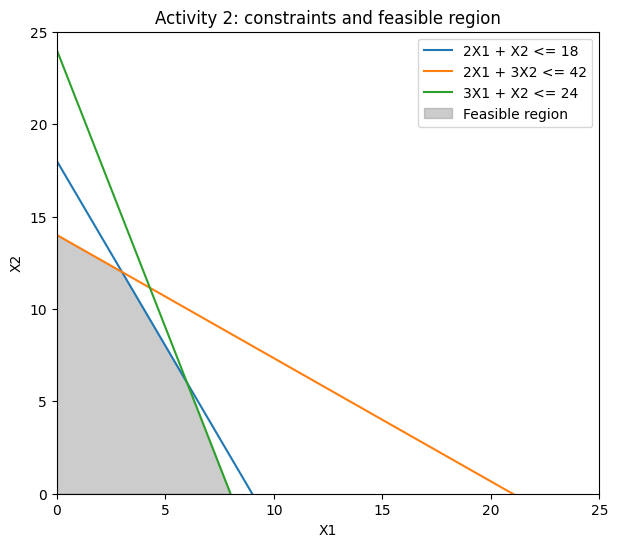

In [27]:
# Same approach as Section 1: express each constraint as X2 in terms of X1 and plot it.
X1g = np.linspace(0, 25, 500)

C1 = 18 - 2 * X1g            # 2X1 +  X2 <= 18  ->  X2 = 18 - 2X1
C2 = (42 - 2 * X1g) / 3      # 2X1 + 3X2 <= 42  ->  X2 = (42 - 2X1)/3
C3 = 24 - 3 * X1g            # 3X1 +  X2 <= 24  ->  X2 = 24 - 3X1

# Feasible X2 for each X1 is the smallest of the three upper bounds, where that is still >= 0
upper = np.minimum(np.minimum(C1, C2), C3)
inside = upper >= 0

plt.figure(figsize=(7, 6))
plt.plot(X1g, C1, label='2X1 + X2 <= 18')
plt.plot(X1g, C2, label='2X1 + 3X2 <= 42')
plt.plot(X1g, C3, label='3X1 + X2 <= 24')
plt.fill_between(X1g[inside], 0, upper[inside], color='grey', alpha=0.4, label='Feasible region')

plt.xlim(0, 25); plt.ylim(0, 25)
plt.xlabel('X1'); plt.ylabel('X2')
plt.legend()
plt.title('Activity 2: constraints and feasible region');

In [28]:
# Corner points: every pair of boundary lines that meet inside every other constraint.
# (0,0)  axes
# (8,0)  X2 = 0 and 3X1 + X2 = 24
# (6,6)  3X1 + X2 = 24 and 2X1 + X2 = 18   (subtract: X1 = 6, then X2 = 6)
# (3,12) 2X1 + X2 = 18 and 2X1 + 3X2 = 42  (subtract: 2X2 = 24, X2 = 12, X1 = 3)
# (0,14) X1 = 0 and 2X1 + 3X2 = 42
# The crossing of 3X1 + X2 = 24 with 2X1 + 3X2 = 42 is at X1 = 30/7, X2 = 78/7, which breaks 2X1 + X2 <= 18, so it is not a corner.
corners = [(0, 0), (8, 0), (6, 6), (3, 12), (0, 14)]

def Z2(x1, x2):
    return 5 * x1 + 3 * x2

print(f"{'corner':>10} {'2X1+X2<=18':>11} {'2X1+3X2<=42':>12} {'3X1+X2<=24':>11} {'Z':>6}")
for x1, x2 in corners:
    print(f"{str((x1, x2)):>10} {str(2*x1 + x2 <= 18):>11} {str(2*x1 + 3*x2 <= 42):>12} {str(3*x1 + x2 <= 24):>11} {Z2(x1, x2):>6}")

best = max(corners, key=lambda p: Z2(*p))
print(f"\noptimal corner: X1 = {best[0]}, X2 = {best[1]}, Z = {Z2(*best)}")

    corner  2X1+X2<=18  2X1+3X2<=42  3X1+X2<=24      Z
    (0, 0)        True         True        True      0
    (8, 0)        True         True        True     40
    (6, 6)        True         True        True     48
   (3, 12)        True         True        True     51
   (0, 14)        True         True        True     42

optimal corner: X1 = 3, X2 = 12, Z = 51


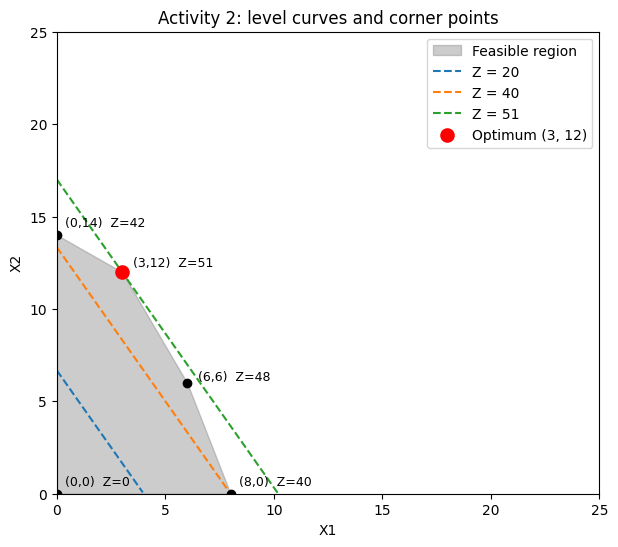

In [29]:
# Level curves of the objective, as in Section 1. Z = 5X1 + 3X2  ->  X2 = (Z - 5X1)/3
plt.figure(figsize=(7, 6))
plt.fill_between(X1g[inside], 0, upper[inside], color='grey', alpha=0.4, label='Feasible region')
for N in [20, 40, 51]:
    lvl = (N - 5 * X1g) / 3
    keep = lvl >= 0
    plt.plot(X1g[keep], lvl[keep], '--', label=f'Z = {N}')
cx, cy = zip(*corners)
plt.scatter(cx, cy, color='black', zorder=5)
offsets = {(0, 0): (6, 6), (8, 0): (6, 6), (6, 6): (8, 2), (3, 12): (8, 4), (0, 14): (6, 6)}
for x1, x2 in corners:
    plt.annotate(f'({x1},{x2})  Z={Z2(x1, x2):g}', (x1, x2), textcoords='offset points', xytext=offsets[(x1, x2)], fontsize=9)
plt.scatter([best[0]], [best[1]], color='red', s=90, zorder=6, label='Optimum (3, 12)')
plt.xlim(0, 25); plt.ylim(0, 25)
plt.xlabel('X1'); plt.ylabel('X2')
plt.legend(loc='upper right')
plt.title('Activity 2: level curves and corner points');

The level curve for $Z = 51$ touches the feasible region at the single point $(3, 12)$, where $2X_1 + X_2 \\le 18$ and $2X_1 + 3X_2 \\le 42$ both hold with equality. Any larger $Z$ pushes the line clear of the grey area, so $X_1 = 3$, $X_2 = 12$, $Z = 51$ is the optimum.

***

### <font color='red'> Activity 3: A factory makes products A ($40 profit, 2 hours) and B ($30 profit, 1 hour) on one machine with at most 40 hours a week. Formulate the LP and solve it. </font>

corner   (0, 0)  hours used =   0  profit = $0
corner  (20, 0)  hours used =  40  profit = $800
corner  (0, 40)  hours used =  40  profit = $1200

optimal: a = 0, b = 40, profit = $1200
profit per machine hour: A = $20/h, B = $30/h


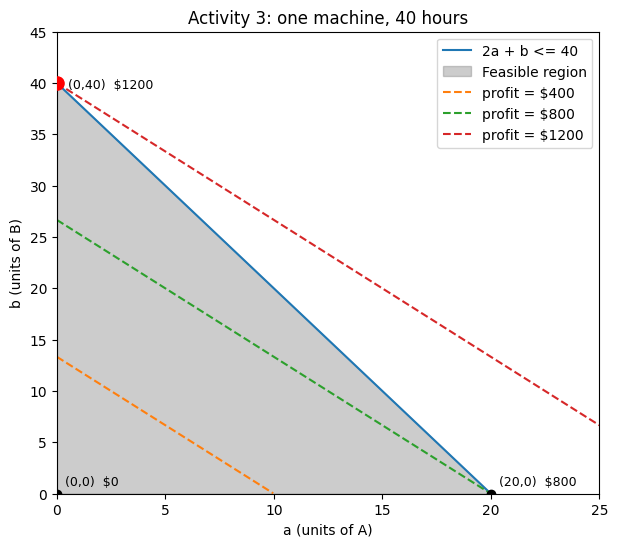

In [30]:
# Decision variables: a = units of A, b = units of B per week
# Maximize   40a + 30b
# subject to  2a + b <= 40      (machine hours)
#             a, b >= 0

A1 = np.linspace(0, 25, 500)
Bmax = 40 - 2 * A1                       # 2a + b <= 40  ->  b = 40 - 2a
inside3 = Bmax >= 0

plt.figure(figsize=(7, 6))
plt.plot(A1, Bmax, label='2a + b <= 40')
plt.fill_between(A1[inside3], 0, Bmax[inside3], color='grey', alpha=0.4, label='Feasible region')
for N in [400, 800, 1200]:
    lvl = (N - 40 * A1) / 30              # 40a + 30b = N
    keep = lvl >= 0
    plt.plot(A1[keep], lvl[keep], '--', label=f'profit = ${N}')

corners3 = [(0, 0), (20, 0), (0, 40)]
def profit(a, b): return 40 * a + 30 * b
offsets3 = {(0, 0): (6, 6), (20, 0): (6, 6), (0, 40): (8, -4)}
for a, b in corners3:
    plt.scatter(a, b, color='red' if (a, b) == (0, 40) else 'black', s=90 if (a, b) == (0, 40) else 36, zorder=5)
    plt.annotate(f'({a},{b})  ${profit(a, b)}', (a, b), textcoords='offset points', xytext=offsets3[(a, b)], fontsize=9)
plt.xlim(0, 25); plt.ylim(0, 45)
plt.xlabel('a (units of A)'); plt.ylabel('b (units of B)')
plt.legend(loc='upper right')
plt.title('Activity 3: one machine, 40 hours');

for a, b in corners3:
    print(f"corner {str((a, b)):>8}  hours used = {2 * a + b:>3}  profit = ${profit(a, b)}")
best3 = max(corners3, key=lambda p: profit(*p))
print(f"\noptimal: a = {best3[0]}, b = {best3[1]}, profit = ${profit(*best3)}")
print(f"profit per machine hour: A = ${40 / 2:.0f}/h, B = ${30 / 1:.0f}/h")

Only one resource is limited, so the answer is whichever product earns more per machine hour. A earns \$20 an hour and B earns \$30, so the machine should run B for all 40 hours: 40 units of B, no units of A, \$1200 a week. The level curve for \$1200 meets the feasible region only at $(0, 40)$.

***

### <font color='red'> Activity 4: Simplex. Z = 18X1 + 12.5X2 subject to X1 + X2 <= 20, X1 <= 12, X2 <= 16. The report solves this by hand. This cell runs the same pivots in exact fractions so the two can be compared tableau for tableau. </font>

In [31]:
def simplex(c, A, b, names=None):
    """Tableau simplex for  maximize c.x  subject to  A x <= b,  x >= 0,  b >= 0.

    One slack per constraint gives the starting basis. Entering variable: most negative
    entry in the objective row. Leaving variable: minimum ratio b_i / a_ij over rows with
    a_ij > 0. Stops when no objective entry is negative. Fractions keep every tableau exact.
    """
    m, n = len(A), len(c)
    names = names or [f"x{j+1}" for j in range(n)]
    names = names + [f"s{i+1}" for i in range(m)]
    T = [[Fraction(x) for x in A[i]] + [Fraction(int(i == j)) for j in range(m)] + [Fraction(b[i])] for i in range(m)]
    T.append([-Fraction(x) for x in c] + [Fraction(0)] * m + [Fraction(0)])
    basis = [n + i for i in range(m)]

    def show(title):
        print(title)
        print(f"{'basis':>6} | " + " ".join(f"{v:>7}" for v in names) + " |     RHS")
        for i, row in enumerate(T):
            label = names[basis[i]] if i < m else "Z"
            print(f"{label:>6} | " + " ".join(f"{str(x):>7}" for x in row[:-1]) + f" | {str(row[-1]):>7}")
        print()

    show("Initial tableau")
    it = 0
    while True:
        z = T[-1]
        col = min(range(n + m), key=lambda j: z[j])
        if z[col] >= 0:
            break
        ratios = [(T[i][-1] / T[i][col], i) for i in range(m) if T[i][col] > 0]
        if not ratios:
            print("unbounded"); return None
        row = min(ratios)[1]
        it += 1
        print(f"Iteration {it}: {names[col]} enters (Z row entry {z[col]}), "
              f"ratios {[f'{names[basis[i]]}: {r}' for r, i in ratios]}, {names[basis[row]]} leaves. "
              f"Pivot on {T[row][col]} at (row {names[basis[row]]}, column {names[col]}).")
        p = T[row][col]
        T[row] = [x / p for x in T[row]]
        for i in range(m + 1):
            if i != row and T[i][col] != 0:
                f = T[i][col]
                T[i] = [a - f * bb for a, bb in zip(T[i], T[row])]
        basis[row] = col
        show(f"Tableau after iteration {it}")

    x = [Fraction(0)] * n
    for i, bi in enumerate(basis):
        if bi < n:
            x[bi] = T[i][-1]
    print("Optimal:", ", ".join(f"{names[j]} = {x[j]}" for j in range(n)), f", Z = {T[-1][-1]}")
    print("Basic variables:", [names[bi] for bi in basis])
    return x, T[-1][-1]

In [32]:
x_opt, z_opt = simplex([18, Fraction(25, 2)], [[1, 1], [1, 0], [0, 1]], [20, 12, 16], names=["X1", "X2"])

Initial tableau
 basis |      X1      X2      s1      s2      s3 |     RHS
    s1 |       1       1       1       0       0 |      20
    s2 |       1       0       0       1       0 |      12
    s3 |       0       1       0       0       1 |      16
     Z |     -18   -25/2       0       0       0 |       0

Iteration 1: X1 enters (Z row entry -18), ratios ['s1: 20', 's2: 12'], s2 leaves. Pivot on 1 at (row s2, column X1).
Tableau after iteration 1
 basis |      X1      X2      s1      s2      s3 |     RHS
    s1 |       0       1       1      -1       0 |       8
    X1 |       1       0       0       1       0 |      12
    s3 |       0       1       0       0       1 |      16
     Z |       0   -25/2       0      18       0 |     216

Iteration 2: X2 enters (Z row entry -25/2), ratios ['s1: 8', 's3: 16'], s1 leaves. Pivot on 1 at (row s1, column X2).
Tableau after iteration 2
 basis |      X1      X2      s1      s2      s3 |     RHS
    X2 |       0       1       1      -1      

In [33]:
# Cross-checks: the simplex reaches the same corners the graphical method found in Activities 2 and 3
print("Activity 2 by simplex:")
simplex([5, 3], [[2, 1], [2, 3], [3, 1]], [18, 42, 24], names=["X1", "X2"])
print("\nActivity 3 by simplex:")
simplex([40, 30], [[2, 1]], [40], names=["a", "b"]);

Activity 2 by simplex:
Initial tableau
 basis |      X1      X2      s1      s2      s3 |     RHS
    s1 |       2       1       1       0       0 |      18
    s2 |       2       3       0       1       0 |      42
    s3 |       3       1       0       0       1 |      24
     Z |      -5      -3       0       0       0 |       0

Iteration 1: X1 enters (Z row entry -5), ratios ['s1: 9', 's2: 21', 's3: 8'], s3 leaves. Pivot on 3 at (row s3, column X1).
Tableau after iteration 1
 basis |      X1      X2      s1      s2      s3 |     RHS
    s1 |       0     1/3       1       0    -2/3 |       2
    s2 |       0     7/3       0       1    -2/3 |      26
    X1 |       1     1/3       0       0     1/3 |       8
     Z |       0    -4/3       0       0     5/3 |      40

Iteration 2: X2 enters (Z row entry -4/3), ratios ['s1: 6', 's2: 78/7', 'X1: 24'], s1 leaves. Pivot on 1/3 at (row s1, column X2).
Tableau after iteration 2
 basis |      X1      X2      s1      s2      s3 |     RHS
   

***